# Import

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets

# Neuron

In [42]:
# A neuron is a computational unit that receives one or more inputs, 
# applies weights to these inputs, sums them up, 
# and then passes the sum through an activation function to produce an output.

import numpy as np

class Neuron:
    """
    A class representing a single neuron in a neural network.

    Attributes:
        activation (function): Activation function to apply to the neuron's output.
        initialization (str): Initialization method for weights ('xavier' or 'he').
        learning_rate_schedule (bool): Whether to apply learning rate scheduling during training.
    """

    def __init__(self, activation):
        """
        Initialize the neuron with specified activation function and weight initialization method.

        Args:
            activation (str): Name of the activation function.
            initialization (str, optional): Initialization method for weights. Defaults to 'xavier'.
            learning_rate_schedule (bool, optional): Whether to apply learning rate scheduling during training. Defaults to False.
        """
        self.activation = self._get_activation(activation)
        self.weights = None
        self.bias = None

    def _get_activation(self, activation):
        """
        Get the activation function based on the provided name.

        Args:
            activation (str): Name of the activation function.

        Returns:
            function: Activation function corresponding to the provided name.

        Raises:
            ValueError: If the provided activation function name is not supported.
        """
        activation_funcs = {
            'linear':self.linear,
            'step': self.step,
            'sigmoid': self.sigmoid,
            'tanh': self.tanh,
            'relu': self.relu,
            'leaky_relu': self.leaky_relu,
            'softmax': self.softmax
        }
        if activation in activation_funcs:
            return activation_funcs[activation]
        else:
            raise ValueError(f"Activation function '{activation}' not supported.")

    # Activation functions
    @staticmethod
    def linear(x):
        """
        Linear activation function.

        Args:
            x (numpy.ndarray): Input data.

        Returns:
            numpy.ndarray: Output after applying linear function.
        """
        return x
    
    @staticmethod
    def step(x):
        """
        Step activation function.

        Args:
            x (numpy.ndarray): Input data.

        Returns:
            numpy.ndarray: Output after applying step function.
        """
        return np.where(x > 0, 1, 0)

    @staticmethod
    def sigmoid(x):
        """
        Sigmoid activation function.

        Args:
            x (numpy.ndarray): Input data.

        Returns:
            numpy.ndarray: Output after applying sigmoid function.
        """
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def tanh(x):
        """
        Hyperbolic tangent activation function.

        Args:
            x (numpy.ndarray): Input data.

        Returns:
            numpy.ndarray: Output after applying hyperbolic tangent function.
        """
        return np.tanh(x)

    @staticmethod
    def relu(x):
        """
        Rectified Linear Unit (ReLU) activation function.

        Args:
            x (numpy.ndarray): Input data.

        Returns:
            numpy.ndarray: Output after applying ReLU function.
        """
        return np.maximum(0, x)

    @staticmethod
    def leaky_relu(x, alpha=0.01):
        """
        Leaky ReLU activation function.

        Args:
            x (numpy.ndarray): Input data.
            alpha (float, optional): Slope of the negative part. Defaults to 0.01.

        Returns:
            numpy.ndarray: Output after applying Leaky ReLU function.
        """
        return np.where(x > 0, x, alpha * x)

    @staticmethod
    def softmax(x):
        """
        Softmax activation function.

        Args:
            x (numpy.ndarray): Input data.

        Returns:
            numpy.ndarray: Output after applying softmax function.
        """
        exp_values = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_values / np.sum(exp_values, axis=1, keepdims=True)


# Perceptron

In [43]:
# It takes multiple binary inputs, applies weights to them, sums them up, 
# and then passes the sum through an activation function, 
# typically a step function, to produce a binary output.
#
# Perceptrons are typically used for binary classification tasks and can only learn linear decision boundaries.

import numpy as np

class Perceptron:
    """
    A simple perceptron classifier.

    Attributes:
        learning_rate (float): The learning rate for training.
        n_iters (int): The number of iterations for training.
        neuron (Neuron): The neuron instance used for classification.
    """

    def __init__(self, learning_rate=0.01, n_iters=1000):
        """
        Initialize the perceptron.

        Args:
            learning_rate (float, optional): The learning rate for training. Defaults to 0.01.
            n_iters (int, optional): The number of iterations for training. Defaults to 1000.
        """
        self.neuron = Neuron(activation="step")
        self.learning_rate = learning_rate
        self.n_iters = n_iters

    def fit(self, X, y):
        """
        Fit the perceptron to the training data.

        Args:
            X (numpy.ndarray): The input features.
            y (numpy.ndarray): The target labels.
        """
        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.neuron.weights = np.zeros(n_features)
        self.neuron.bias = 0

        # Training loop
        for _ in range(self.n_iters):
            # Iterate through each sample
            for i in range(n_samples):
                # Compute prediction
                linear_output = np.dot(X[i], self.neuron.weights) + self.neuron.bias
                prediction = self.neuron.activation(linear_output)

                # Update weights and bias if prediction is incorrect
                if prediction != y[i]:
                    self.neuron.weights += self.learning_rate * y[i] * X[i]
                    self.neuron.bias += self.learning_rate * y[i]

    def predict(self, X):
        """
        Predict the labels for input data.

        Args:
            X (numpy.ndarray): The input features.

        Returns:
            numpy.ndarray: Predicted labels.
        """
        n_samples = X.shape[0]
        predictions = np.zeros(n_samples)
        for i in range(n_samples):
            linear_output = np.dot(X[i], self.neuron.weights) + self.neuron.bias
            predictions[i] = self.neuron.activation(linear_output)
        return predictions.astype(int)


# Kernel Perceptron

In [44]:
class KernelPerceptron:
    """
    Kernelized perceptron classifier.

    Attributes:
        kernel (function): Kernel function to compute the dot product in feature space.
        learning_rate (float): The learning rate for training.
        n_iters (int): The number of iterations for training.
        alpha (numpy.ndarray): Mistake counter vector.
        X_train (numpy.ndarray): The training features.
        y_train (numpy.ndarray): The training labels.
    """

    def __init__(self, kernel, learning_rate=0.01, n_iters=1000):
        """
        Initialize the kernelized perceptron.

        Args:
            kernel (function): Kernel function.
            learning_rate (float, optional): The learning rate for training. Defaults to 0.01.
            n_iters (int, optional): The number of iterations for training. Defaults to 1000.
        """
        self.kernel = kernel
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.alpha = None
        self.bias = 0
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Fit the kernelized perceptron to the training data.

        Args:
            X (numpy.ndarray): The input features.
            y (numpy.ndarray): The target labels.
        """
        n_samples = X.shape[0]

        # Initialize mistake counter vector alpha
        self.alpha = np.zeros(n_samples)
        self.X_train = X
        self.y_train = y
        self.bias = 0

        # Training loop
        for _ in range(self.n_iters):
            # Iterate through each training example
            for j in range(n_samples):
                prediction = self.predict_single(X[j])
                if prediction != y[j]:
                    self.alpha[j] += 1
                    self.bias += prediction

    def predict_single(self, x):
        """
        Predict the label for a single input using kernelized perceptron.

        Args:
            x (numpy.ndarray): The input feature.

        Returns:
            int: Predicted label (-1 or 1).
        """
        linear_output = 0
        for i in range(len(self.X_train)):
            linear_output += (self.alpha[i] * self.y_train[i] * self.kernel(self.X_train[i], x)) + self.bias
        return np.sign(linear_output)

    def predict(self, X):
        """
        Predict labels for a set of input features.

        Args:
            X (numpy.ndarray): The input features.

        Returns:
            numpy.ndarray: Predicted labels.
        """
        y_pred = []
        for x in X:
            y_pred.append(self.predict_single(x))
        return np.array(y_pred)


# Test Perceptron

## XOR

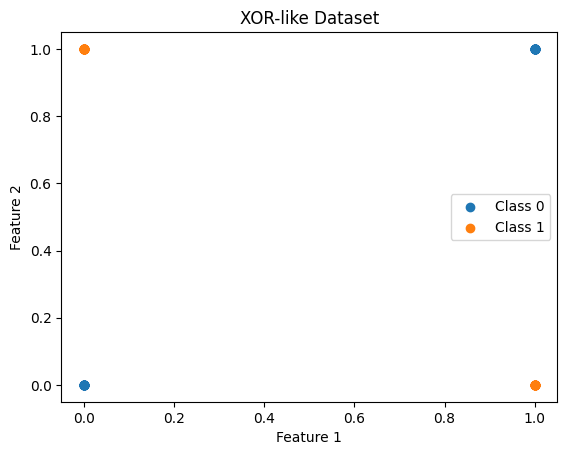

In [59]:
import numpy as np

def generate_xor_dataset(n_samples):
    """
    Generate a XOR-like dataset with two features.

    Args:
        n_samples (int): Number of samples to generate.

    Returns:
        tuple: Tuple containing input features (X) and target labels (y).
    """
    X = np.random.randint(0, 2, size=(n_samples, 2))
    y = np.logical_xor(X[:, 0], X[:, 1]).astype(int)
    return X, y

# Generate XOR-like dataset
X_xor, y_xor = generate_xor_dataset(n_samples=100)

# Plot XOR-like dataset
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], label='Class 0')
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('XOR-like Dataset')
plt.legend()
plt.show()


### Perceptron

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron

# Split the dataset into training and testing sets
X_train_xor, X_test_xor, y_train_xor, y_test_xor = train_test_split(X_xor, y_xor, test_size=0.2, random_state=42)

# Initialize and train the perceptron
perceptron = Perceptron()
perceptron.fit(X_train_xor, y_train_xor)

# Predict labels for the test set
y_pred_perceptron = perceptron.predict(X_test_xor)

# Calculate accuracy
accuracy_perceptron = accuracy_score(y_test_xor, y_pred_perceptron)
print("Perceptron Accuracy:", accuracy_perceptron)


Perceptron Accuracy: 0.7


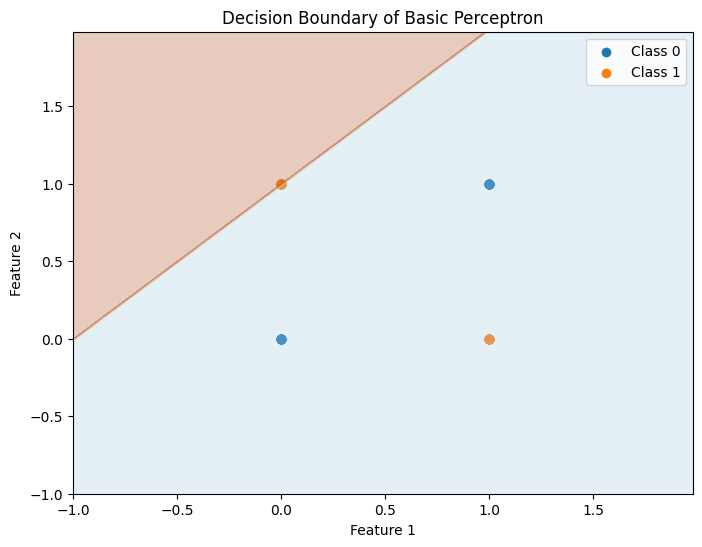

In [61]:
# Plot decision boundary for the basic perceptron
plt.figure(figsize=(8, 6))
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], label='Class 0')
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], label='Class 1')

# Generate grid points for decision boundary
x_min, x_max = X_xor[:, 0].min() - 1, X_xor[:, 0].max() + 1
y_min, y_max = X_xor[:, 1].min() - 1, X_xor[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary of Basic Perceptron')
plt.legend()
plt.show()


### Kernel Perceptron

In [66]:
# Define RBF kernel function
def rbf_kernel(x1, x2, gamma=0.1):
    return np.exp(-gamma * np.linalg.norm(x1 - x2)**2)

# Initialize and train the kernel perceptron
kernel_perceptron = KernelPerceptron(kernel=rbf_kernel)
kernel_perceptron.fit(X_train_xor, y_train_xor)

# Predict labels for the test set
y_pred_kernel_perceptron = kernel_perceptron.predict(X_test_xor)

# Calculate accuracy
accuracy_kernel_perceptron = accuracy_score(y_test_xor, y_pred_kernel_perceptron)
print("Kernel Perceptron Accuracy:", accuracy_kernel_perceptron)


Kernel Perceptron (RBF Kernel) Accuracy: 0.3


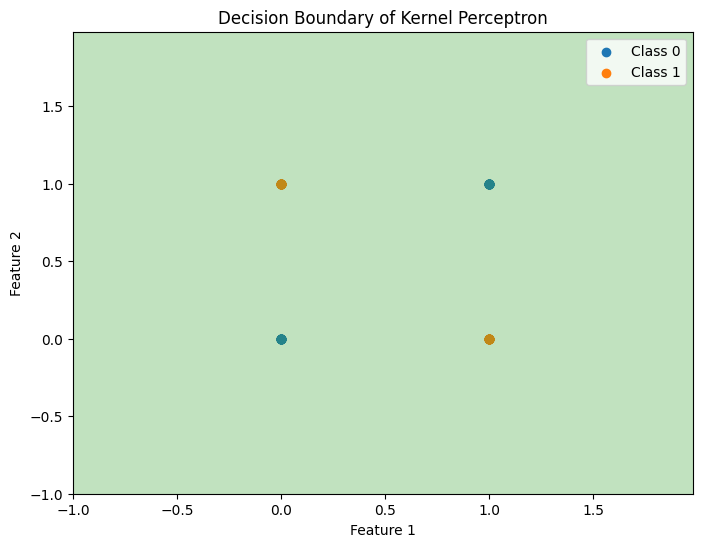

In [65]:
# Plot decision boundary for the kernel perceptron
plt.figure(figsize=(8, 6))
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], label='Class 0')
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], label='Class 1')

# Generate grid points for decision boundary
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = kernel_perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary of Kernel Perceptron')
plt.legend()
plt.show()


In [67]:
def evaluate_kernel_perceptron(X_train, X_test, y_train, y_test, gamma_values):
    """
    Evaluate the kernel perceptron with different gamma values.

    Args:
        X_train (numpy.ndarray): The training features.
        X_test (numpy.ndarray): The testing features.
        y_train (numpy.ndarray): The training labels.
        y_test (numpy.ndarray): The testing labels.
        gamma_values (list): List of gamma values to try.
    """
    for gamma in gamma_values:
        # Define RBF kernel function with current gamma
        rbf_kernel = lambda x1, x2: np.exp(-gamma * np.linalg.norm(x1 - x2)**2)

        # Initialize and train the kernel perceptron with RBF kernel
        kernel_perceptron = KernelPerceptron(kernel=rbf_kernel)
        kernel_perceptron.fit(X_train, y_train)

        # Predict labels for the test set
        y_pred = kernel_perceptron.predict(X_test)

        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)
        print(f"Gamma = {gamma}, Accuracy = {accuracy}")


In [68]:
# Define the range of gamma values to try
gamma_values = [0.1, 1, 10]

# Evaluate the kernel perceptron with different gamma values
evaluate_kernel_perceptron(X_train_xor, X_test_xor, y_train_xor, y_test_xor, gamma_values)


Gamma = 0.1, Accuracy = 0.3
Gamma = 1, Accuracy = 0.3
Gamma = 10, Accuracy = 0.3


## Iris and Hard

In [45]:
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Function to load and split Iris dataset
def load_and_split_iris(test_size=0.2, random_state=None):
    iris = load_iris()
    X = iris.data
    y = iris.target
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    return X_train, X_test, y_train, y_test

# Function to generate and split Hard dataset
def generate_and_split_hard(test_size=0.2, random_state=None):
    X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=random_state)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    return X_train, X_test, y_train, y_test

In [46]:
# Load and split Iris dataset
X_train_iris, X_test_iris, y_train_iris, y_test_iris = load_and_split_iris(test_size=0.2, random_state=42)

# Generate and split Hard dataset
X_train_hard, X_test_hard, y_train_hard, y_test_hard = generate_and_split_hard(test_size=0.2, random_state=42)

In [47]:
# Function to train Perceptron
def train_perceptron(X_train, y_train, learning_rate=0.01, n_iters=1000):
    perceptron = Perceptron(learning_rate=learning_rate, n_iters=n_iters)
    perceptron.fit(X_train, y_train)
    return perceptron

# Function to train KernelPerceptron
def train_kernel_perceptron(X_train, y_train, kernel, learning_rate=0.01, n_iters=1000):
    kernel_perceptron = KernelPerceptron(kernel=kernel, learning_rate=learning_rate, n_iters=n_iters)
    kernel_perceptron.fit(X_train, y_train)
    return kernel_perceptron

# Function to test a classifier and return accuracy
def test_classifier(classifier, X_test, y_test):
    y_pred = classifier.predict(X_test)
    return accuracy_score(y_test, y_pred)

In [48]:
# Train Perceptron on Iris dataset
perceptron_iris = train_perceptron(X_train_iris, y_train_iris)
accuracy_perceptron_iris = test_classifier(perceptron_iris, X_test_iris, y_test_iris)
print("Perceptron accuracy on Iris dataset:", accuracy_perceptron_iris)

# Train KernelPerceptron with linear kernel on Iris dataset
kernel_perceptron_iris = train_kernel_perceptron(X_train_iris, y_train_iris, kernel=np.dot)
accuracy_kernel_perceptron_iris = test_classifier(kernel_perceptron_iris, X_test_iris, y_test_iris)
print("KernelPerceptron accuracy with linear kernel on Iris dataset:", accuracy_kernel_perceptron_iris)

Perceptron accuracy on Iris dataset: 0.3
KernelPerceptron accuracy with linear kernel on Iris dataset: 0.3


In [54]:
import matplotlib.pyplot as plt

def plot_dataset(X, y, feature_names=None, target_names=None):
    """
    Plot all pairs of features against each other for a given dataset.

    Args:
        X (numpy.ndarray): Input features.
        y (numpy.ndarray): Target labels.
        feature_names (list, optional): Names of features. Defaults to None.
        target_names (list, optional): Names of target classes. Defaults to None.
    """
    num_features = X.shape[1]

    if feature_names is None:
        feature_names = [f'Feature {i+1}' for i in range(num_features)]

    if target_names is None:
        target_names = [f'Class {i+1}' for i in range(len(set(y)))]

    plt.figure(figsize=(12, 8))
    for i in range(num_features):
        for j in range(i+1, num_features):
            plt.subplot(num_features, num_features, i*num_features + j + 1)
            for target in range(len(set(y))):
                plt.scatter(X[y == target, i], X[y == target, j], label=target_names[target])
            plt.xlabel(feature_names[i])
            plt.ylabel(feature_names[j])
            plt.legend()
    plt.tight_layout()
    plt.show()


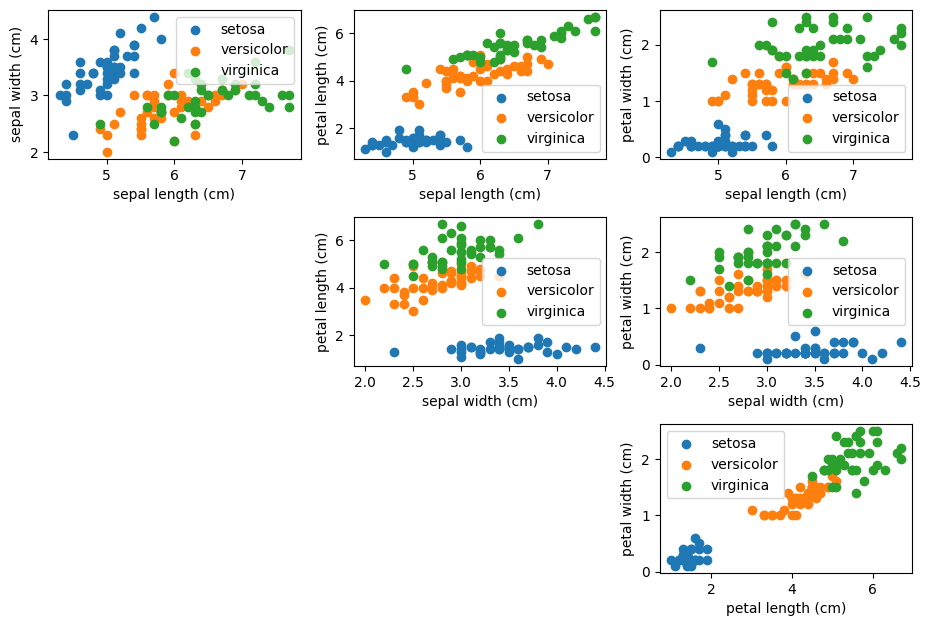

In [55]:
iris = load_iris()

# Plot Iris dataset
plot_dataset(X_train_iris, y_train_iris, feature_names=iris.feature_names, target_names=iris.target_names)

ValueError: num must be an integer with 1 <= num <= 6, not 7

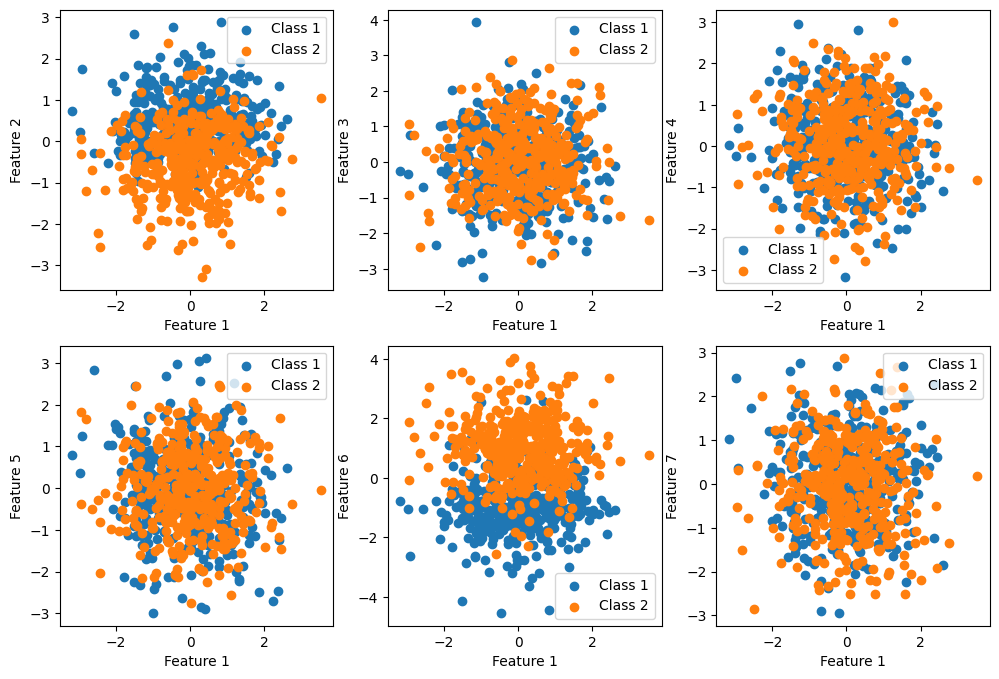

In [58]:
# Plot Hard dataset
plot_dataset(X_train_hard, y_train_hard)


# MLP

In [49]:
class MLP:
    def __init__(self, input_neurons=1, output_neurons=1, inner_layers=[0], learning_rate=0.01, n_iters=1000):
        self.input_neurons = input_neurons
        self.output_neurons = output_neurons
        self.inner_layers = inner_layers
        self.neurons = self.create_network()
        self.learning_rate = learning_rate
        self.n_iters = n_iters

        if len(inner_layers) < 0:
            raise ValueError("At least two layers are needed for an MLP.")
        
    def create_network(self):
        """
        Create the neural network with the specified architecture.

        Returns:
            list: List of neuron layers.
        """
        neurons = []

        # Input layer
        input_layer = [Neuron() for _ in range(self.input_neurons)]
        neurons.append(input_layer)

        # Inner layers
        for num_neurons in self.inner_layers:
            inner_layer = [Neuron() for _ in range(num_neurons)]
            neurons.append(inner_layer)

        # Output layer
        output_layer = [Neuron() for _ in range(self.output_neurons)]
        neurons.append(output_layer)

        return neurons

    def fit(self, X, y):
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                predicted = self.predict(x_i)
                errors = [y[idx] - predicted[-1]]
                for layer_idx in reversed(range(len(self.layers) - 1)):
                    errors.append(np.dot(errors[-1], self.neurons[layer_idx].weights.T))
                errors.reverse()
                for layer_idx, neuron in enumerate(self.neurons):
                    neuron.fit(X[idx], errors[layer_idx], self.learning_rate)

    def predict(self, X):
        outputs = [X]
        output = X
        for neuron in self.neurons:
            output = neuron.predict(output)
            outputs.append(output)
        return outputs

    def get_weights(self):
        return [neuron.weights for neuron in self.neurons]

    def get_biases(self):
        return [neuron.bias for neuron in self.neurons]


In [50]:
def accuracy(y_true, y_pred):
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    return accuracy

X, y = datasets.make_blobs(
    n_samples=150, n_features=2, centers=2, cluster_std=1.05, random_state=2
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

In [51]:
p = Perceptron(learning_rate=0.01, n_iters=1000)
p.fit(X_train, y_train)
predictions = p.predict(X_test)

print("Perceptron classification accuracy", accuracy(y_test, predictions))

Perceptron classification accuracy 0.5


In [52]:
def plot_perceptron_decision_boundary(X_train, y_train, p):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)

    plt.scatter(X_train[:, 0], X_train[:, 1], marker="o", c=y_train, cmap=plt.cm.coolwarm)

    x0_1 = np.amin(X_train[:, 0])
    x0_2 = np.amax(X_train[:, 0])

    x1_1 = (-1 * p.get_weights()[0] * x0_1 - p.get_bias()) / p.get_weights()[1]
    x1_2 = (-1 * p.get_weights()[0] * x0_2 - p.get_bias()) / p.get_weights()[1]

    ax.plot([x0_1, x0_2], [x1_1, x1_2], "k")

    ymin = np.amin(X_train[:, 1])
    ymax = np.amax(X_train[:, 1])
    ax.set_ylim([ymin - 3, ymax + 3])

    # Create a grid of points
    xx, yy = np.meshgrid(np.linspace(x0_1, x0_2, 100), np.linspace(ymin - 3, ymax + 3, 100))
    Z = p.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary as a color gradient
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.2)

    plt.show()

AttributeError: 'Perceptron' object has no attribute 'get_weights'

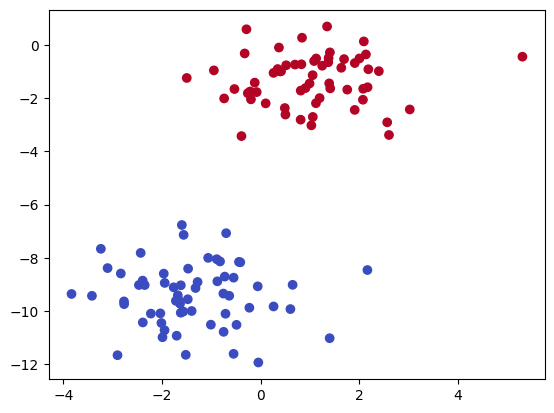

In [53]:
plot_perceptron_decision_boundary(X_train, y_train, p)

In [ ]:
mlp = MLP(layers=[2, 4, 1], learning_rate=0.01, n_iters=1000)
mlp.fit(X_train, y_train)
predictions = mlp.predict(X_test)
print(predictions)

ValueError: Activation function '4' not supported.

: 